In [3]:
!pip install pandas
!pip install seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------------------------- ------ 6.8/8.1 MB 38.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 35.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 35.8 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -------------------

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [6]:
data = pd.read_csv("Dataset/kidney_disease.csv")

**Data Pre-processing**

In [7]:
data.head() # it will print top 5 rows

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [8]:
data.tail() # it will print last 5

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [9]:
data.head(20) # it will print first 20 rows

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [10]:
data.tail(20) # it will print last 20 rows

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
380,380,59.0,60.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,54,6500,4.9,no,no,no,good,no,no,notckd
381,381,71.0,70.0,1.025,0.0,0.0,NaN,NaN,notpresent,notpresent,...,40,5800,5.9,no,no,no,good,no,no,notckd
382,382,48.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,6000,6.5,no,no,no,good,no,no,notckd
383,383,80.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,49,5100,5.0,no,no,no,good,no,no,notckd
384,384,57.0,60.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,42,11000,4.5,no,no,no,good,no,no,notckd
385,385,63.0,70.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,52,8000,5.1,no,no,no,good,no,no,notckd
386,386,46.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,43,5700,6.5,no,no,no,good,no,no,notckd
387,387,15.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,50,6200,5.2,no,no,no,good,no,no,notckd
388,388,51.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,46,9500,6.4,no,no,no,good,no,no,notckd
389,389,41.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,52,7200,5.8,no,no,no,good,no,no,notckd


In [11]:
data.drop(["id"], axis = 1, inplace = True) # it will drop(remove) id column

In [12]:
data.columns # it gives all columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [13]:
data.info() # it gives information of data mean data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [14]:
data.describe() # it computes summary values for continuos column data mean std,mean,count etc

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [15]:
data['classification'].unique() #return unique value of classification column

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [16]:
data['classification']=data['classification'].replace("ckd","ckd\t") #replace ckt by ckd\t
data['classification'].unique()

array(['ckd\t', 'notckd'], dtype=object)

In [17]:
np.unique(data.dtypes, return_counts=True)

(array([dtype('float64'), dtype('O')], dtype=object), array([11, 14]))

In [18]:
catcols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
print(catcols)

['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [19]:
from collections import Counter as c
for i in catcols:
  print("columns:",i)
  print(c(data[i])) # using counter for checking number of classes in cloumn
  print('*'*120 + '\n')

columns: rbc
Counter({'normal': 201, nan: 152, 'abnormal': 47})
************************************************************************************************************************

columns: pc
Counter({'normal': 259, 'abnormal': 76, nan: 65})
************************************************************************************************************************

columns: pcc
Counter({'notpresent': 354, 'present': 42, nan: 4})
************************************************************************************************************************

columns: ba
Counter({'notpresent': 374, 'present': 22, nan: 4})
************************************************************************************************************************

columns: htn
Counter({'no': 251, 'yes': 147, nan: 2})
************************************************************************************************************************

columns: dm
Counter({'no': 258, 'yes': 134, '\tno': 3, '\tyes': 2, nan: 2, ' yes'

In [20]:
for col in ['rbc', 'rc', 'wc', 'pcv']:
    if col in catcols:
        catcols.remove(col)

In [21]:
cont_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
print(cont_cols)

['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


In [22]:
from collections import Counter as c
for i in cont_cols:
  print("Continuos columns:",i)
  print(c(data[i])) # using counter for checking number of classes in cloumn
  print('*'*120 + '\n')

Continuos columns: age
Counter({60.0: 19, 65.0: 17, 48.0: 12, 50.0: 12, 55.0: 12, 47.0: 11, 62.0: 10, 45.0: 10, 54.0: 10, 59.0: 10, 56.0: 10, 61.0: 9, 70.0: 9, 46.0: 9, 34.0: 9, 68.0: 8, 73.0: 8, 64.0: 8, 71.0: 8, 57.0: 8, 63.0: 7, 72.0: 7, 67.0: 7, 30.0: 7, 42.0: 6, 69.0: 6, 35.0: 6, 44.0: 6, 43.0: 6, 33.0: 6, 51.0: 5, 52.0: 5, 53.0: 5, 75.0: 5, 76.0: 5, 58.0: 5, 41.0: 5, 66.0: 5, 24.0: 4, 40.0: 4, 39.0: 4, 80.0: 4, 23.0: 4, 74.0: 3, 38.0: 3, 17.0: 3, 8.0: 3, 32.0: 3, 37.0: 3, 25.0: 3, 29.0: 3, 21.0: 2, 15.0: 2, 5.0: 2, 12.0: 2, 49.0: 2, 19.0: 2, 36.0: 2, 20.0: 2, 28.0: 2, 7.0: 1, nan: 1, 82.0: 1, 11.0: 1, 26.0: 1, nan: 1, nan: 1, nan: 1, nan: 1, 81.0: 1, 14.0: 1, 27.0: 1, nan: 1, 83.0: 1, 4.0: 1, 3.0: 1, 6.0: 1, nan: 1, 90.0: 1, 78.0: 1, nan: 1, 2.0: 1, nan: 1, 22.0: 1, 79.0: 1})
************************************************************************************************************************

Continuos columns: bp
Counter({80.0: 116, 70.0: 112, 60.0: 71, 90.0: 53, 100.0: 25, 5

In [23]:
cont_cols.remove('su')
cont_cols.remove('bp')
cont_cols.remove('sg')
print(cont_cols)

['age', 'al', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


In [24]:
cont_cols.append('rc')
cont_cols.append('pcv')
cont_cols.append('wc')
cont_cols.append('rbc')
print(cont_cols)

['age', 'al', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'rc', 'pcv', 'wc', 'rbc']


In [25]:
# catcols.add('rbc') # rbc should be numerical
print(catcols)

['pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [26]:
print(cont_cols)

['age', 'al', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'rc', 'pcv', 'wc', 'rbc']


**Rectifying the Categorical Cloumn CLasses**

In [27]:
data['cad'] = data.cad.replace('\tno','no')
c(data['cad'])

Counter({'no': 364, 'yes': 34, nan: 2})

In [28]:
data['dm'] = data.dm.replace('\tno','no')
c(data['dm'])

Counter({'no': 261, 'yes': 134, '\tyes': 2, nan: 2, ' yes': 1})

**Null Value Checking**

In [29]:
data.isnull().any()

age                True
bp                 True
sg                 True
al                 True
su                 True
rbc                True
pc                 True
pcc                True
ba                 True
bgr                True
bu                 True
sc                 True
sod                True
pot                True
hemo               True
pcv                True
wc                 True
rc                 True
htn                True
dm                 True
cad                True
appet              True
pe                 True
ane                True
classification    False
dtype: bool

In [30]:
data.isnull().sum()

age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

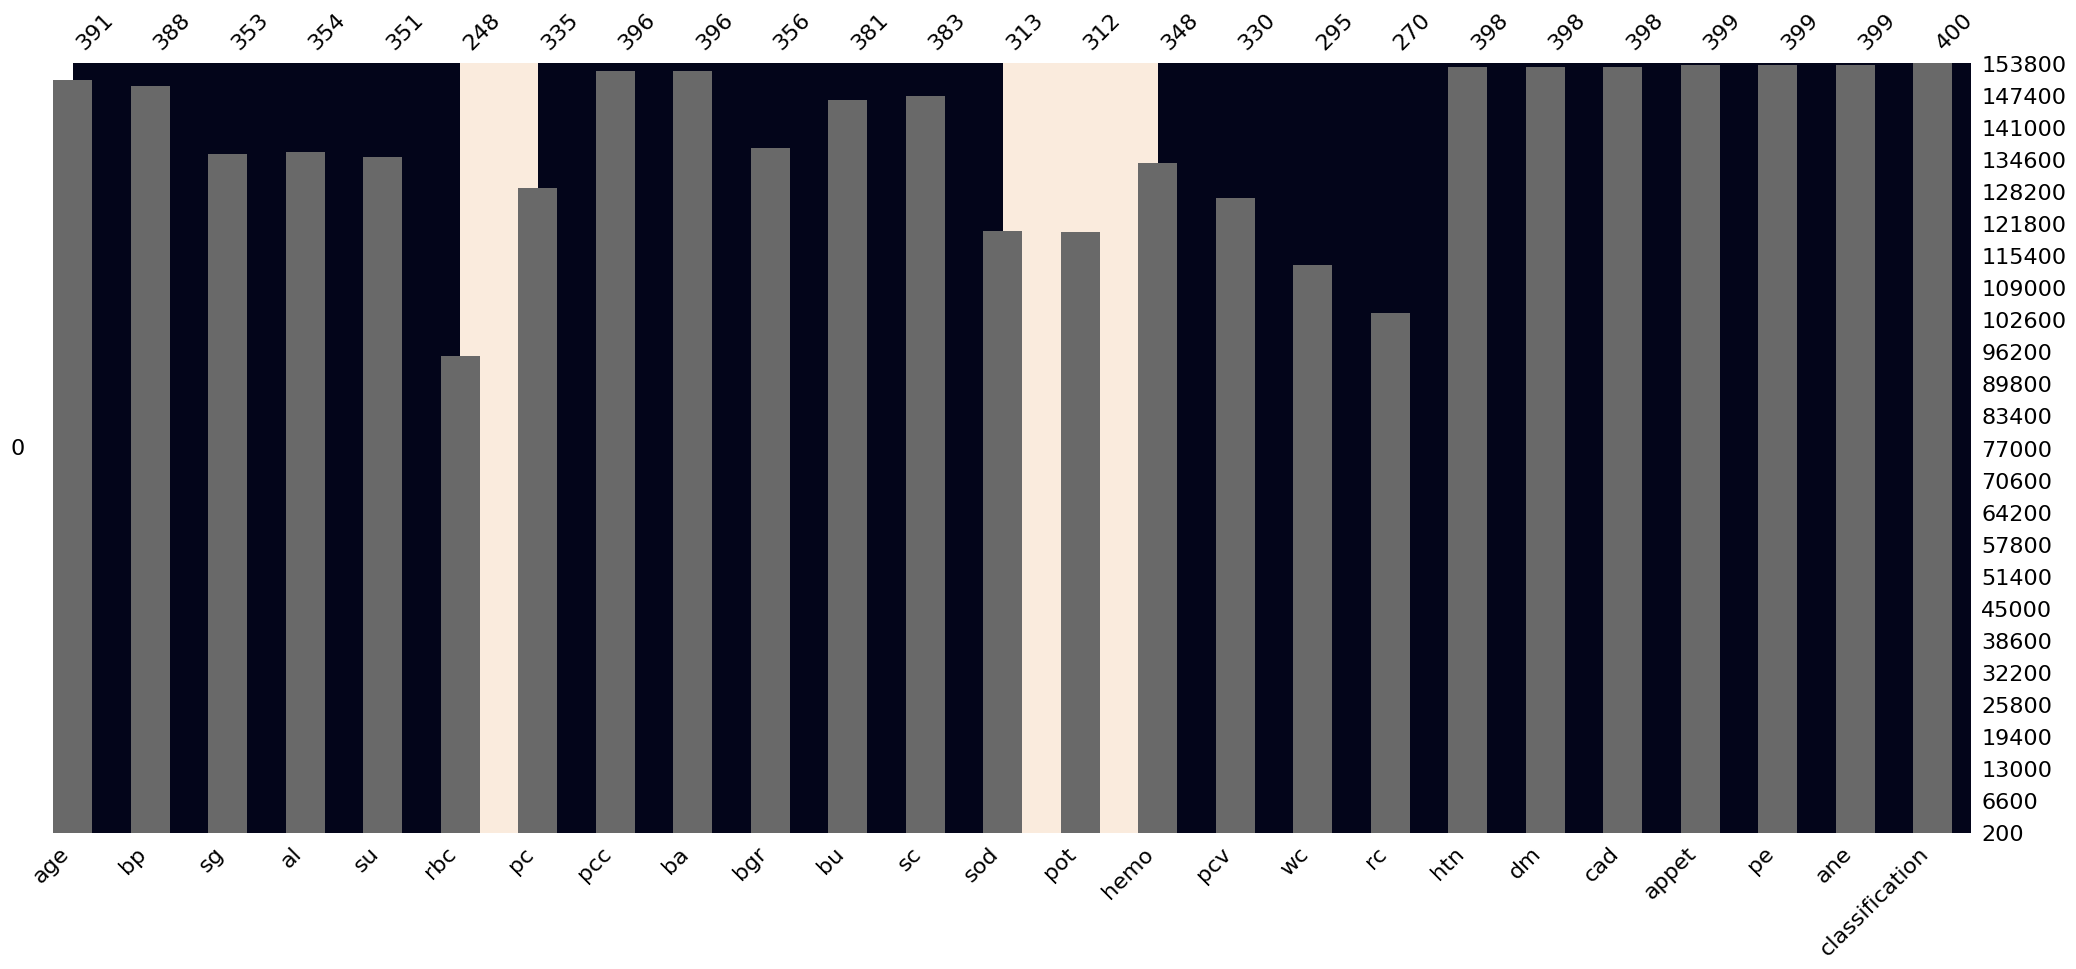

In [32]:
import missingno as msno

sns.heatmap(data.isnull(),cbar=False)

msno.bar(data)
plt.show()

In [33]:
data.pcv = pd.to_numeric(data.pcv, errors='coerce')
data.wc = pd.to_numeric(data.wc, errors='coerce')

**Handling Continuos/numerical Columns Null Values**


In [34]:
data['bgr'].fillna(data['bgr'].mean(),inplace=True)
data['bp'].fillna(data['bp'].mean(),inplace=True)
data['bu'].fillna(data['bu'].mean(),inplace=True)
data['hemo'].fillna(data['hemo'].mean(),inplace=True)
data['pcv'].fillna(data['pcv'].mean(),inplace=True)
data['pot'].fillna(data['pot'].mean(),inplace=True)
# data['rbc'].fillna(data['rbc'].mean(),inplace=True)
data['sc'].fillna(data['sc'].mean(),inplace=True)
data['sod'].fillna(data['sod'].mean(),inplace=True)
data['wc'].fillna(data['wc'].mean(),inplace=True)

C:\Users\balje\AppData\Local\Temp\ipykernel_17856\4127023313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bgr'].fillna(data['bgr'].mean(),inplace=True)
C:\Users\balje\AppData\Local\Temp\ipykernel_17856\4127023313.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [35]:
for col in catcols:
    if data[col].dtype == 'object':
        # Replace incorrect values and strip whitespace
        data[col] = data[col].str.strip()
        data[col] = data[col].replace(['\t?', '?', '\tno', '\tyes', ' yes'], [np.nan, np.nan, 'no', 'yes', 'yes'])

        # Manually find the mode based on non-null value counts
        value_counts = data[col].value_counts()
        if not value_counts.empty:
            mode_value = value_counts.idxmax()
            data[col].fillna(mode_value, inplace=True)
            print(f"Mode for column {col} (manual): {mode_value}")
        else:
            data[col].fillna('unknown', inplace=True)
            print(f"Filled NaNs in {col} with 'unknown' as no valid values found after cleaning.")


for col in cont_cols:
    if data[col].dtype != 'object':
        data[col].fillna(data[col].mean(),inplace=True)
    else: # Handle numerical columns that were read as objects
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[col].fillna(data[col].mean(),inplace=True)

Mode for column pc (manual): normal
Mode for column pcc (manual): notpresent
Mode for column ba (manual): notpresent
Mode for column htn (manual): no
Mode for column dm (manual): no
Mode for column cad (manual): no
Mode for column appet (manual): good
Mode for column pe (manual): no
Mode for column ane (manual): no
Mode for column classification (manual): ckd


C:\Users\balje\AppData\Local\Temp\ipykernel_17856\3663960484.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mode_value, inplace=True)
C:\Users\balje\AppData\Local\Temp\ipykernel_17856\3663960484.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [36]:
data.isnull().sum()

age                 0
bp                  0
sg                 47
al                  0
su                 49
rbc               400
pc                  0
pcc                 0
ba                  0
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                  0
rc                  0
htn                 0
dm                  0
cad                 0
appet               0
pe                  0
ane                 0
classification      0
dtype: int64

In [37]:
catcols = ['ane','pe','appet','cad','dm','htn','ba','pcc','pc','rbc']

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in catcols:
  print("Label Encoding of :", i)
  print(c(data[i]))
  data[i] = le.fit_transform(data[i])
  print(c(data[i]))
  print("*"*100)

Label Encoding of : ane
Counter({'no': 340, 'yes': 60})
Counter({0: 340, 1: 60})
****************************************************************************************************
Label Encoding of : pe
Counter({'no': 324, 'yes': 76})
Counter({0: 324, 1: 76})
****************************************************************************************************
Label Encoding of : appet
Counter({'good': 318, 'poor': 82})
Counter({0: 318, 1: 82})
****************************************************************************************************
Label Encoding of : cad
Counter({'no': 366, 'yes': 34})
Counter({0: 366, 1: 34})
****************************************************************************************************
Label Encoding of : dm
Counter({'no': 263, 'yes': 137})
Counter({0: 263, 1: 137})
****************************************************************************************************
Label Encoding of : htn
Counter({'no': 253, 'yes': 147})
Counter({0: 253, 1: 147})
**

**Exploratory Analysis**

In [39]:
data.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
count,400.000000,400.000000,353.000000,400.000000,351.000000,400.0,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,0.0,0.810000,0.105000,0.055000,148.036517,...,12.526437,38.884498,8406.122449,4.707435,0.367500,0.34250,0.085000,0.205000,0.190000,0.150000
std,16.974966,13.476298,0.005717,1.272318,1.099191,0.0,0.392792,0.306937,0.228266,74.782634,...,2.716171,8.151081,2523.219976,0.840314,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,22.000000,...,3.100000,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,101.000000,...,10.875000,34.000000,6975.000000,4.500000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,78.234536,1.020000,1.000000,0.000000,0.0,1.000000,0.000000,0.000000,126.000000,...,12.526437,38.884498,8406.122449,4.707435,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,0.0,1.000000,0.000000,0.000000,150.000000,...,14.625000,44.000000,9400.000000,5.100000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,0.0,1.000000,1.000000,1.000000,490.000000,...,17.800000,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


**Data Visualization**

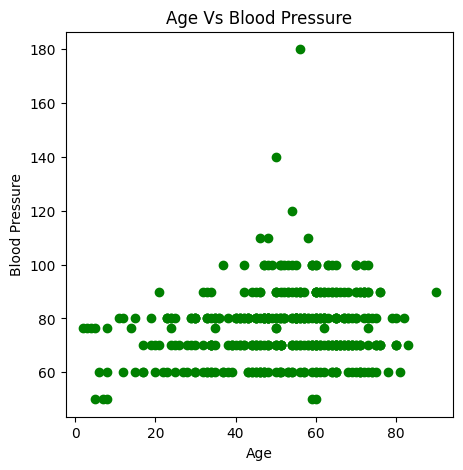

In [40]:

#Age Vs Blood Pressure
fig=plt.figure(figsize=(5,5))
plt.scatter(data['age'],data['bp'],color='green')
plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.title('Age Vs Blood Pressure')
plt.show()

C:\Users\balje\AppData\Local\Temp\ipykernel_17856\4156840497.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.age)


<Axes: xlabel='age', ylabel='Density'>

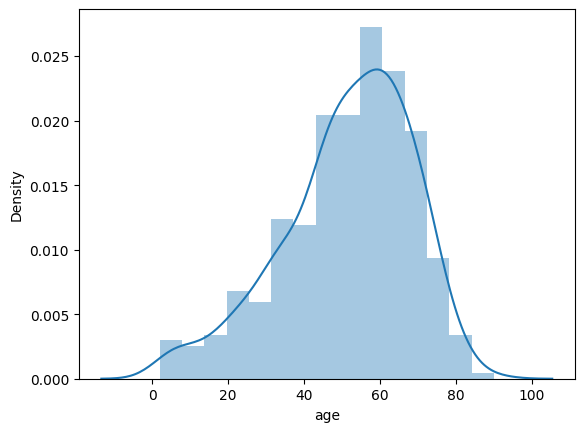

In [41]:
sns.distplot(data.age)

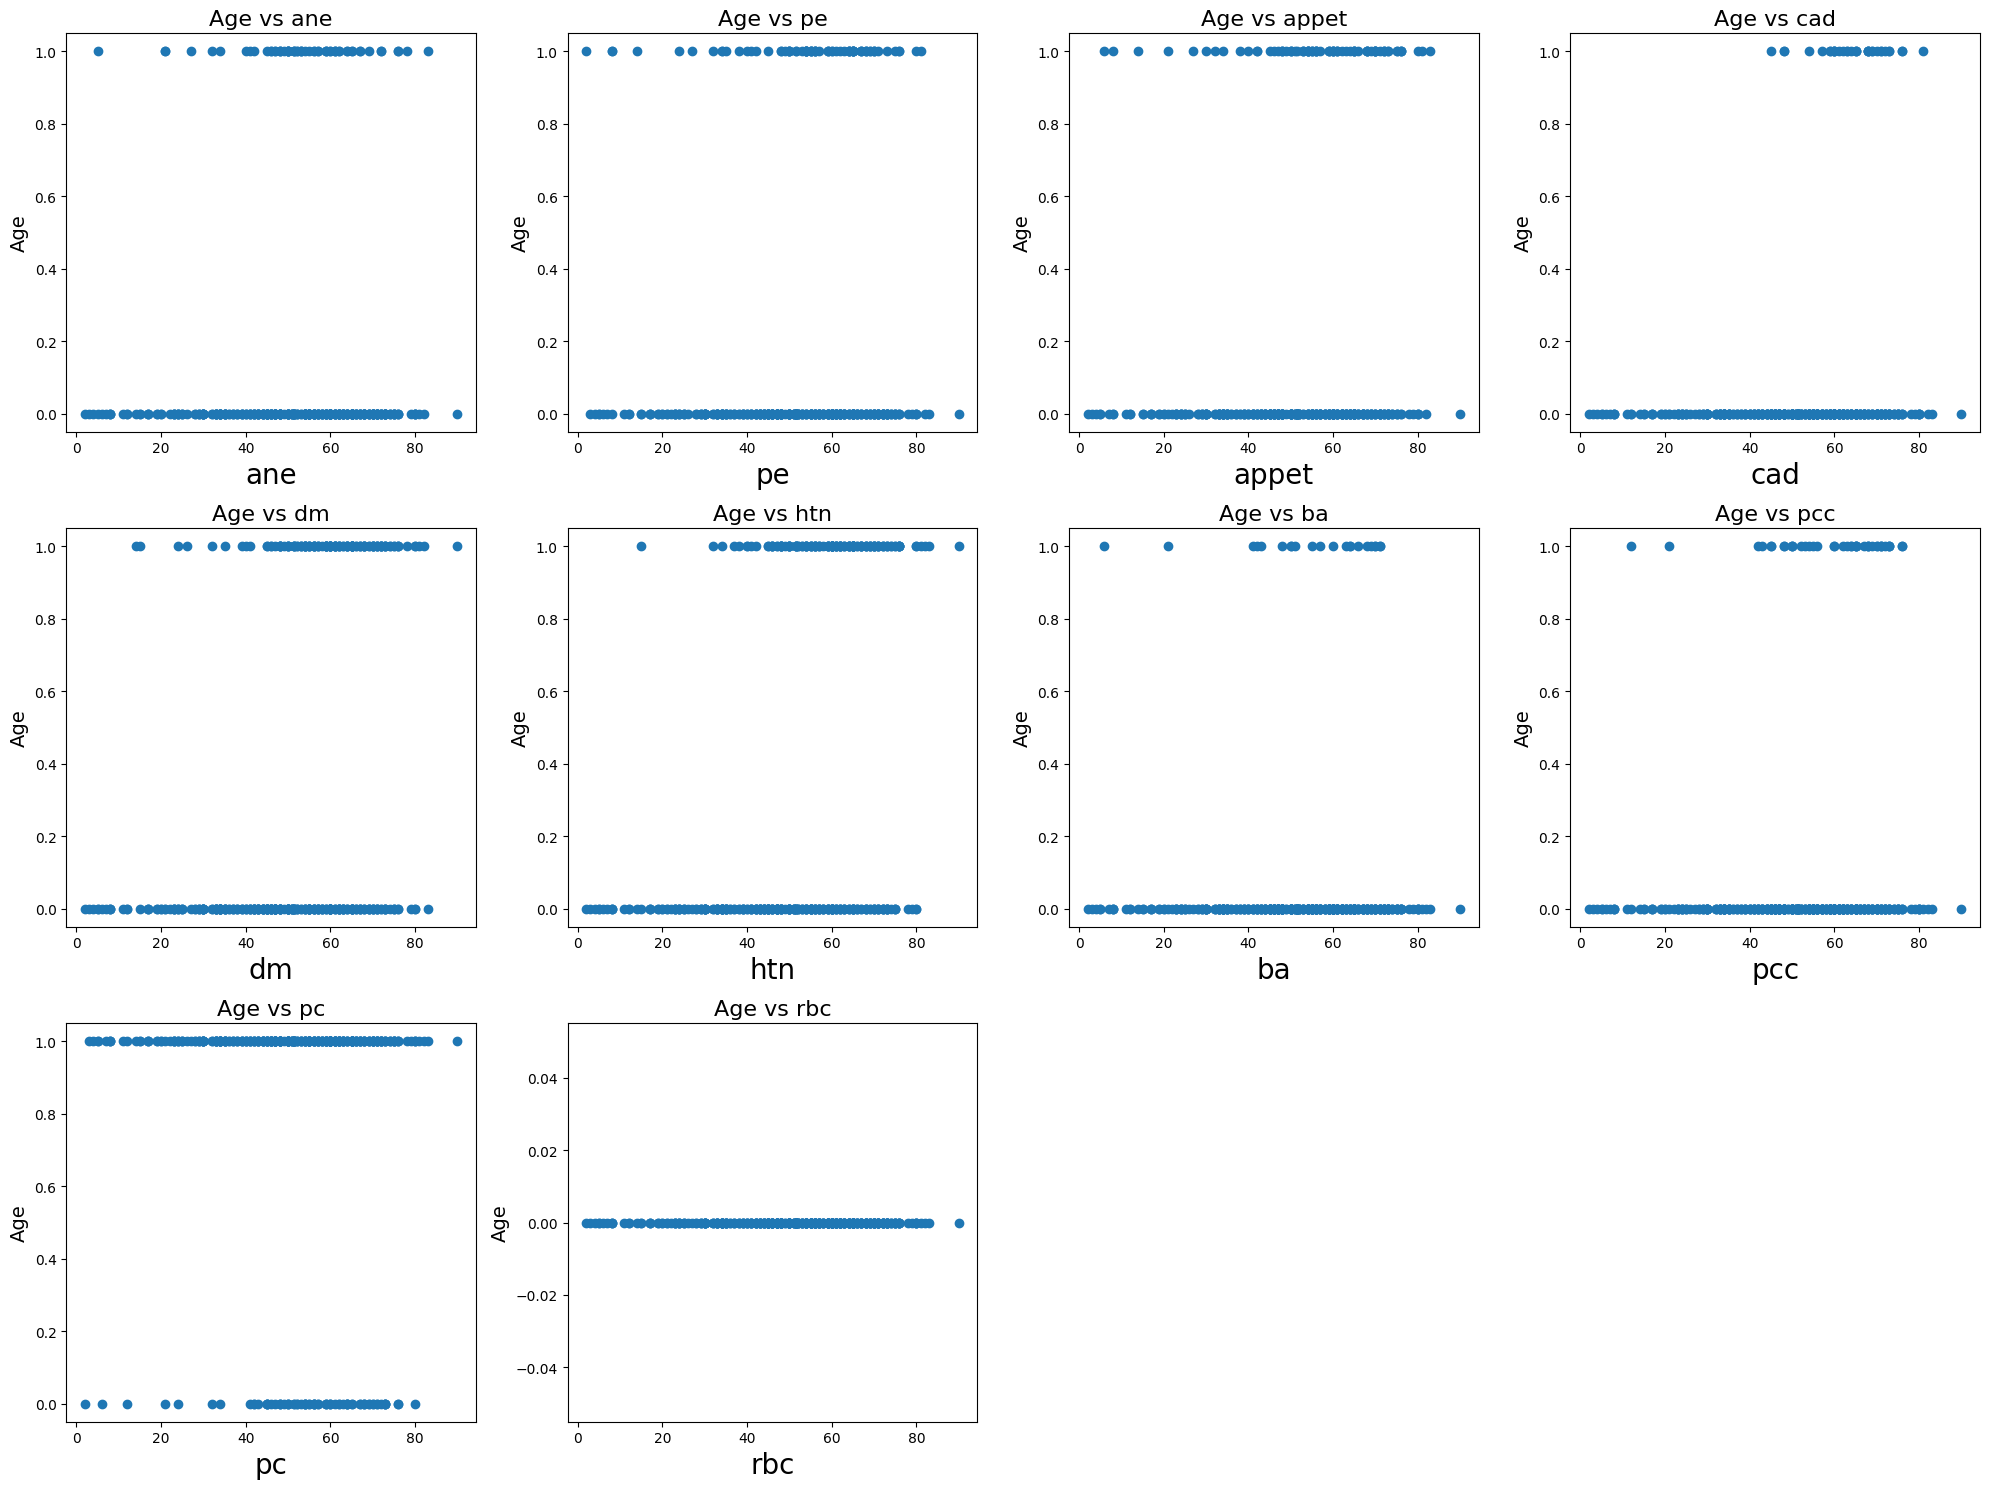

In [42]:
for column in catcols:
    data[column] = pd.Categorical(data[column]).codes
plt.figure(figsize=(20,15),facecolor='white')
plotnumber=1
for column in catcols:
  if plotnumber<=11:
        ax = plt.subplot(3,4,plotnumber) # 3,4 is refer to 3X4 matrix
        plt.scatter(data['age'],data[column]) #plotting scatter plot
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Age', fontsize=14)
        plt.title(f'Age vs {column}', fontsize=16)
        plotnumber+=1
plt.tight_layout()
plt.show()

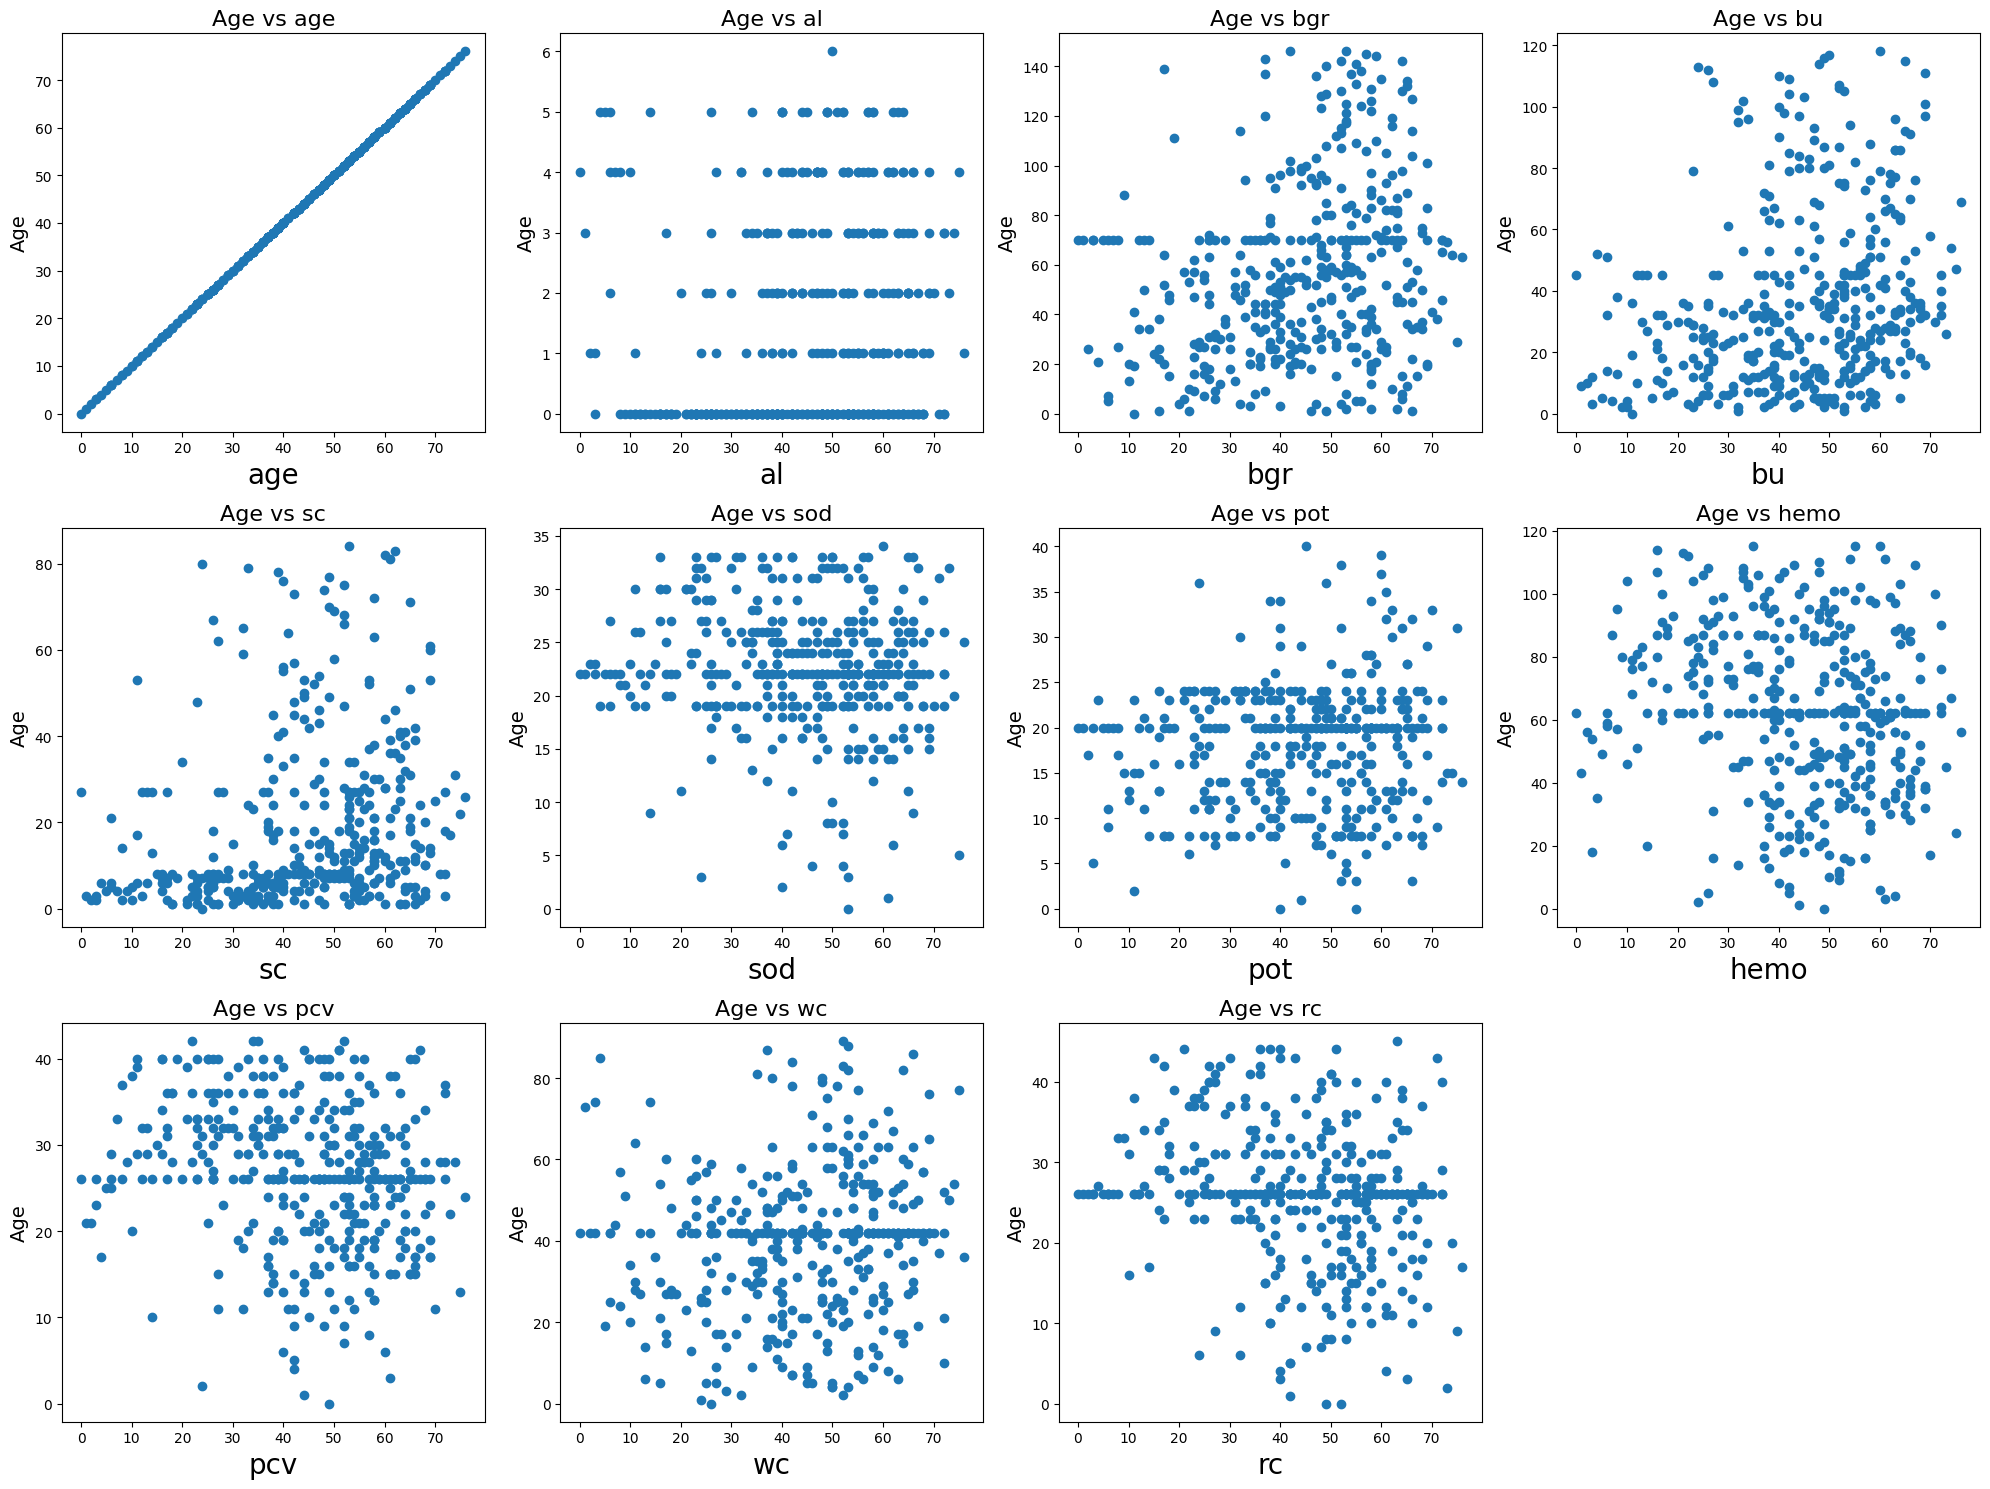

In [43]:
for column in cont_cols:
    data[column] = pd.Categorical(data[column]).codes
plt.figure(figsize=(20,15),facecolor='white')
plotnumber=1
for column in cont_cols:
  if plotnumber<=11:
        ax = plt.subplot(3,4,plotnumber) # 3,4 is refer to 3X4 matrix
        plt.scatter(data['age'],data[column]) #plotting scatter plot
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Age', fontsize=14)
        plt.title(f'Age vs {column}', fontsize=16)
        plotnumber+=1
plt.tight_layout()
plt.show()

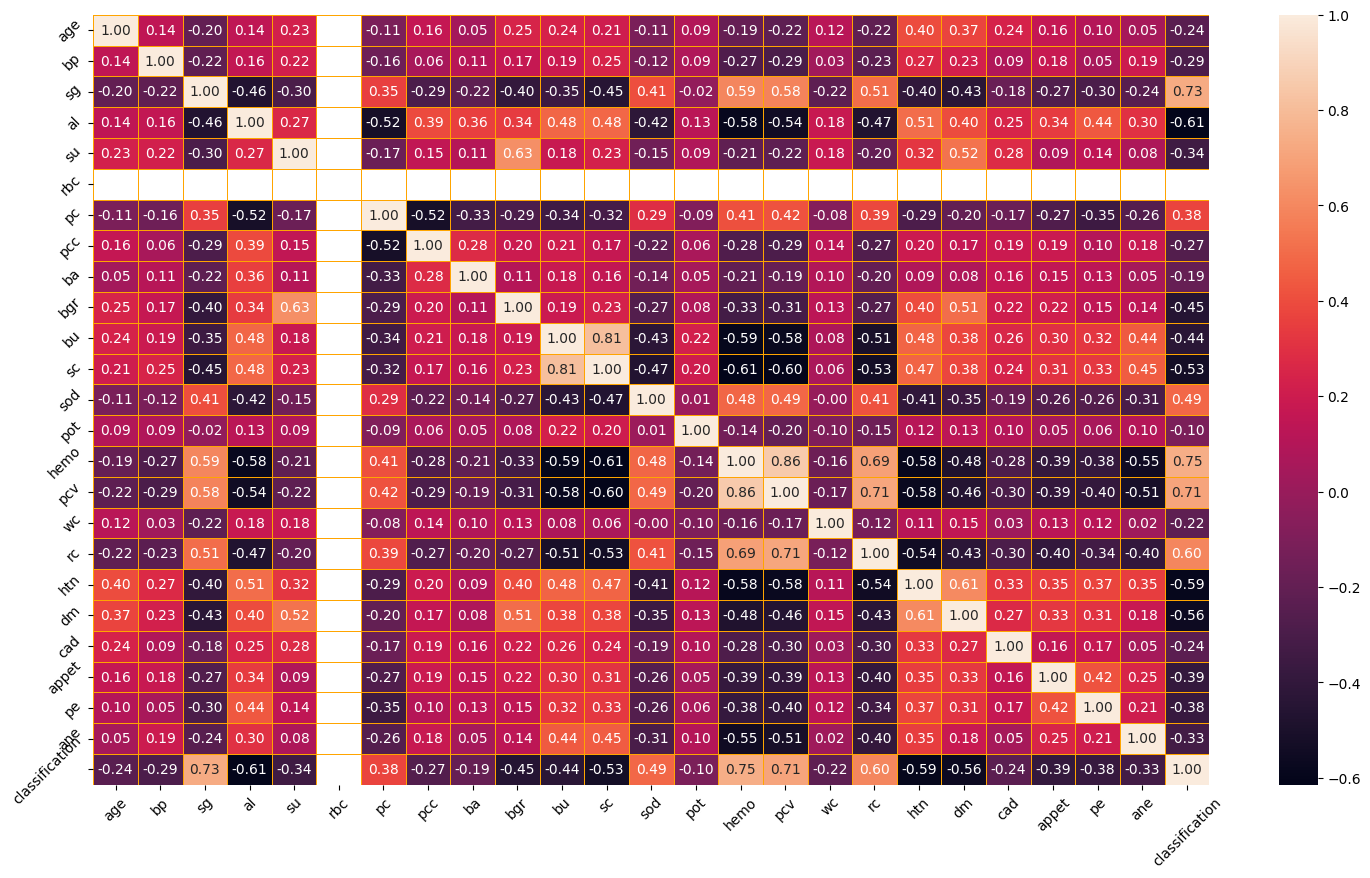

In [44]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['classification'] = le.fit_transform(data['classification'])

#HEAT MAP #correlation of parameters
f,ax=plt.subplots(figsize=(18,10))
sns.heatmap(data.corr(),annot=True,fmt=".2f",ax=ax,linewidths=0.5,linecolor="orange")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

<Axes: ylabel='count'>

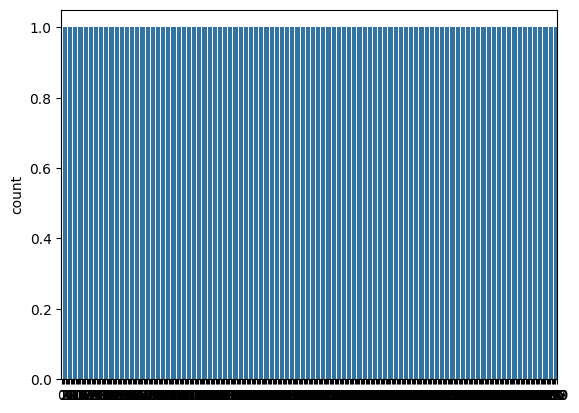

In [45]:
sns.countplot(data['classification'])

In [46]:
# perfroming feature Scaling operation using standard scaller on X part of the dataset because
# there different type of values in the columns
selcols=['rbc','pc','bgr','bu',
         'pe','ane','dm','cad']
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
#x = data.drop(columns=['classification'])
x=pd.DataFrame(data,columns=selcols)
x_bal=sc.fit_transform(x)

In [47]:
x=pd.DataFrame(data,columns=selcols)
y=pd.DataFrame(data,columns=['classification'])

print(x.shape)
print(y.shape)

(400, 8)
(400, 1)


In [48]:
# Splitting the data into train and test

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2) #train test split

print("\nShape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of x_train: (320, 8)
Shape of x_test: (80, 8)
Shape of y_train: (320, 1)
Shape of y_test: (80, 1)


**Tarining The Model in Multiple Algorithm**

In [50]:
#ANN Model
# Importing the Keras libraries and packages
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Creating ANN skleton view
classification = Sequential()
classification.add(Dense(30,activation='relu'))
classification.add(Dense(128,activation='relu'))
classification.add(Dense(64,activation='relu'))
classification.add(Dense(32,activation='relu'))
classification.add(Dense(1,activation='sigmoid'))
# Compiling the ANN model
classification.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Training the model
# Storing the training history
history = classification.fit(x_train,y_train,batch_size=10,validation_split=0.2,epochs=500)

Epoch 1/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5547 - loss: 1.3083 - val_accuracy: 0.6562 - val_loss: 0.5746
Epoch 2/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6016 - loss: 0.5792 - val_accuracy: 0.6562 - val_loss: 0.5636
Epoch 3/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6328 - loss: 0.6030 - val_accuracy: 0.6562 - val_loss: 0.5639
Epoch 4/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6133 - loss: 0.5606 - val_accuracy: 0.6094 - val_loss: 0.5730
Epoch 5/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6133 - loss: 0.5621 - val_accuracy: 0.6406 - val_loss: 0.5563
Epoch 6/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6328 - loss: 0.5453 - val_accuracy: 0.6250 - val_loss: 0.5306
Epoch 7/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6523 - loss: 0.5181 - val_accuracy: 0.6250 - val_loss: 0.5278
Epoch 8/500
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6719 - loss: 0.5078 - val_accuracy: 0.6250 - v

In [51]:
#Random forest Model
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=10,criterion='entropy')

In [52]:
# Fit the model
# We use .ravel() on y_train to fix the DataConversionWarning
rfc.fit(x_train,y_train)

c:\coding\PROJECT\CKD\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
# Make predictions
y_predict = rfc.predict(x_test)
y_predict_train = rfc.predict(x_train)
print("\nRandom Forest Test Predictions:", y_predict)



Random Forest Test Predictions: [0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0]


In [54]:
print("Random Forest Train Predictions:", y_predict_train)

Random Forest Train Predictions: [0 1 0 1 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1
 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1 1 0
 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 1
 0 0 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0
 1 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 1 0 0
 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 1 0
 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0]


In [55]:
#Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(max_depth=4,splitter='best',criterion='entropy')

# Fit the model
# Using .ravel() on y_train to prevent DataConversionWarning
dtc.fit(x_train,y_train)

# Make predictions
y_predict = dtc.predict(x_test)
y_predict_train = dtc.predict(x_train)

print("\nDecision Tree Test Predictions:", y_predict)



Decision Tree Test Predictions: [0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0]


In [56]:
print("Decision Tree Train Predictions:", y_predict_train)

Decision Tree Train Predictions: [0 1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0
 1 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1
 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 1 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 0
 1 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 1 1
 0 0 1 1 1 0 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1
 1 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 0
 1 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 0 1 0
 1 1 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0]


In [57]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression()
lgr.fit(x_train,y_train.values.ravel()) # Use .values.ravel() to prevent DataConversionWarning

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
from sklearn.metrics import accuracy_score,classification_report
y_predict = lgr.predict(x_test)
print("\nLogistic Regression Test Predictions:", y_predict)


Logistic Regression Test Predictions: [0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 1 0 1 1 0]


**Testing the Model**

In [59]:
from sklearn.metrics import accuracy_score,classification_report
# logistic Regression
y_pred = lgr.predict(x_test)
print("\n# logistic Regression")
print(y_pred)
print(x_test)


# logistic Regression
[0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 1 0 1 1 0]
     rbc  pc  bgr  bu  pe  ane  dm  cad
94     0   1   20  51   0    0   1    0
32     0   1   76  26   0    0   1    0
225    0   1  146  74   0    0   1    0
157    0   0   49  29   0    0   1    0
356    0   1   14  25   0    0   0    0
..   ...  ..  ...  ..  ..  ...  ..  ...
188    0   1    7  51   0    0   0    0
223    0   1  130  17   0    0   1    0
65     0   1   70   7   0    0   0    0
262    0   1   45   5   0    0   0    0
186    0   1   70  32   1    0   0    0

[80 rows x 8 columns]


In [60]:
y_pred = dtc.predict(x_test)
print("\n# DecisionTree Classifier")
print(y_pred)


# DecisionTree Classifier
[0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0]


In [61]:
y_pred = rfc.predict(x_test)
print("\n# Random Forest Classifier")
print(y_pred)


# Random Forest Classifier
[0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0]


In [62]:
classification.save("ckd.keras")

In [63]:
y_pred=classification.predict(x_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [64]:
y_pred

array([[8.7038238e-20],
       [1.2317718e-24],
       [0.0000000e+00],
       [2.0867283e-27],
       [9.9999744e-01],
       [3.5163162e-34],
       [0.0000000e+00],
       [0.0000000e+00],
       [8.7321234e-01],
       [0.0000000e+00],
       [0.0000000e+00],
       [1.1280863e-28],
       [7.2380203e-01],
       [7.9180646e-01],
       [3.0151676e-33],
       [1.4616237e-21],
       [0.0000000e+00],
       [9.6025610e-01],
       [8.8540578e-01],
       [0.0000000e+00],
       [7.9053682e-01],
       [9.0570980e-01],
       [0.0000000e+00],
       [8.1013536e-01],
       [0.0000000e+00],
       [9.9300098e-01],
       [0.0000000e+00],
       [6.3627726e-37],
       [1.0000000e+00],
       [0.0000000e+00],
       [1.9826606e-17],
       [7.4279040e-01],
       [2.5019110e-12],
       [7.9713187e-18],
       [0.0000000e+00],
       [8.9858578e-38],
       [8.6604935e-01],
       [5.3820468e-35],
       [1.1475728e-16],
       [9.9999994e-01],
       [7.7611216e-28],
       [1.314919

In [65]:
y_pred=(y_pred>0.5)
y_pred

array([[False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [

In [69]:
def predict_exit(sample_value):
  sample_value=np.array(sample_value)
  sample_value=sample_value.reshape(1,-1)
  sample_value=sc.transform(sample_value)
  return classifier.predict(sample_value)

In [70]:
import numpy as np

new_data_point = np.array([[1,1,121.00000,36.0,0.0,0,1,0]]) # Using values from image
test=classification.predict(new_data_point)
if test > 0.5: # Use > 0.5 for sigmoid output
  print('Prediction:High chance of CKD!')
else:
  print('Prediction:Low chance of CKD')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction:Low chance of CKD


**Testing model with multiple evaluation metrics**

In [71]:
#Compare Model
from sklearn import model_selection


dfs = [] # Initialize dfs as an empty list
models = [
    ('LogReg', LogisticRegression(max_iter=1000)), # Increased max_iter
    ('RF', RandomForestClassifier()),
    ('DecisionTree', DecisionTreeClassifier())
]

results = []
names = []
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc']
target_names = ['NO CKD', 'CKD']
for name, model in models:
    kfold = model_selection.KFold(n_splits=5, shuffle=True, random_state=90210)
    cv_results = model_selection.cross_validate(model, x_train, y_train.values.ravel(), cv=kfold, scoring=scoring) # Use .values.ravel()
    clf = model.fit(x_train, y_train.values.ravel()) # Use .values.ravel()
    y_pred = clf.predict(x_test)
    print(name)
    print(classification_report(y_test, y_pred, target_names=target_names))
    results.append(cv_results)
    names.append(name)
    this_df = pd.DataFrame(cv_results)
    this_df['model'] = name
    dfs.append(this_df)

final = pd.concat(dfs, ignore_index=True)
# return final # Removed return statement

LogReg
              precision    recall  f1-score   support

      NO CKD       1.00      0.89      0.94        54
         CKD       0.81      1.00      0.90        26

    accuracy                           0.93        80
   macro avg       0.91      0.94      0.92        80
weighted avg       0.94      0.93      0.93        80

RF
              precision    recall  f1-score   support

      NO CKD       0.96      0.96      0.96        54
         CKD       0.92      0.92      0.92        26

    accuracy                           0.95        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.95      0.95      0.95        80

DecisionTree
              precision    recall  f1-score   support

      NO CKD       0.91      0.94      0.93        54
         CKD       0.88      0.81      0.84        26

    accuracy                           0.90        80
   macro avg       0.89      0.88      0.88        80
weighted avg       0.90      0.90      0.90        

In [72]:
from sklearn.metrics import confusion_matrix
# Calculate predictions for Logistic Regression
y_predict_lr = lgr.predict(x_test)
cm_lr = confusion_matrix(y_test, y_predict_lr)
cm_lr

array([[48,  6],
       [ 0, 26]])

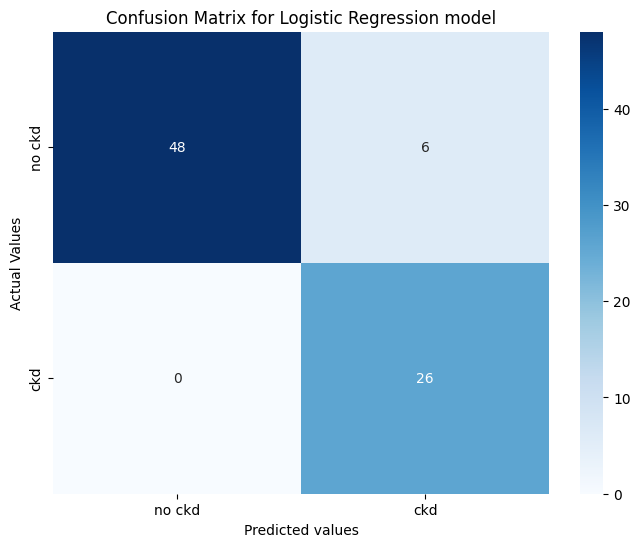

In [73]:
# Plotting confusion matrix for Logistic Regression
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, cmap='Blues', annot=True, xticklabels=['no ckd', 'ckd'], yticklabels=['no ckd', 'ckd'])
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Logistic Regression model')
plt.show()

In [88]:
# Making the Confusion Matrix for RandomForestClassifier
from sklearn.metrics import confusion_matrix
# Calculate predictions for Random Forest
y_predict_rf = rfc.predict(x_test)
cm_rf = confusion_matrix(y_test, y_predict_rf)
cm_rf
print(y_test)
print(y_predict_rf)

     classification
94                0
32                0
225               0
157               0
356               1
..              ...
188               0
223               0
65                0
262               1
186               0

[80 rows x 1 columns]
[0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0]


     classification
94                0
32                0
225               0
157               0
356               1
..              ...
188               0
223               0
65                0
262               1
186               0

[80 rows x 1 columns]
     rbc  pc  bgr  bu  pe  ane  dm  cad
94     0   1   20  51   0    0   1    0
32     0   1   76  26   0    0   1    0
225    0   1  146  74   0    0   1    0
157    0   0   49  29   0    0   1    0
356    0   1   14  25   0    0   0    0
..   ...  ..  ...  ..  ..  ...  ..  ...
188    0   1    7  51   0    0   0    0
223    0   1  130  17   0    0   1    0
65     0   1   70   7   0    0   0    0
262    0   1   45   5   0    0   0    0
186    0   1   70  32   1    0   0    0

[80 rows x 8 columns]


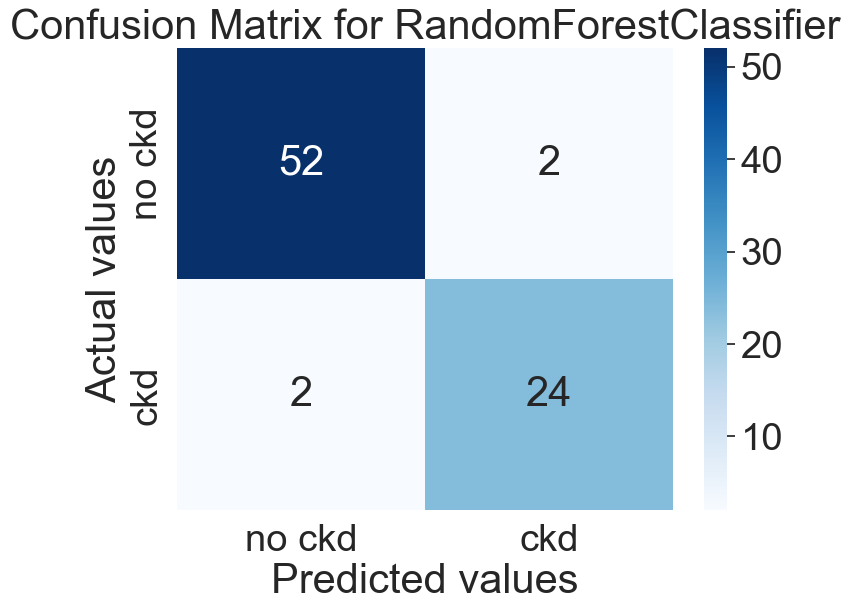

In [87]:
# Plotting confusion matrix for RandomForestClassifier
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, cmap='Blues', annot=True, xticklabels=['no ckd', 'ckd'], yticklabels=['no ckd', 'ckd'])
print(y_test)
print(x_test)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for RandomForestClassifier')
plt.show()

     classification
94                0
32                0
225               0
157               0
356               1
..              ...
188               0
223               0
65                0
262               1
186               0

[80 rows x 1 columns]
     rbc  pc  bgr  bu  pe  ane  dm  cad
94     0   1   20  51   0    0   1    0
32     0   1   76  26   0    0   1    0
225    0   1  146  74   0    0   1    0
157    0   0   49  29   0    0   1    0
356    0   1   14  25   0    0   0    0
..   ...  ..  ...  ..  ..  ...  ..  ...
188    0   1    7  51   0    0   0    0
223    0   1  130  17   0    0   1    0
65     0   1   70   7   0    0   0    0
262    0   1   45   5   0    0   0    0
186    0   1   70  32   1    0   0    0

[80 rows x 8 columns]


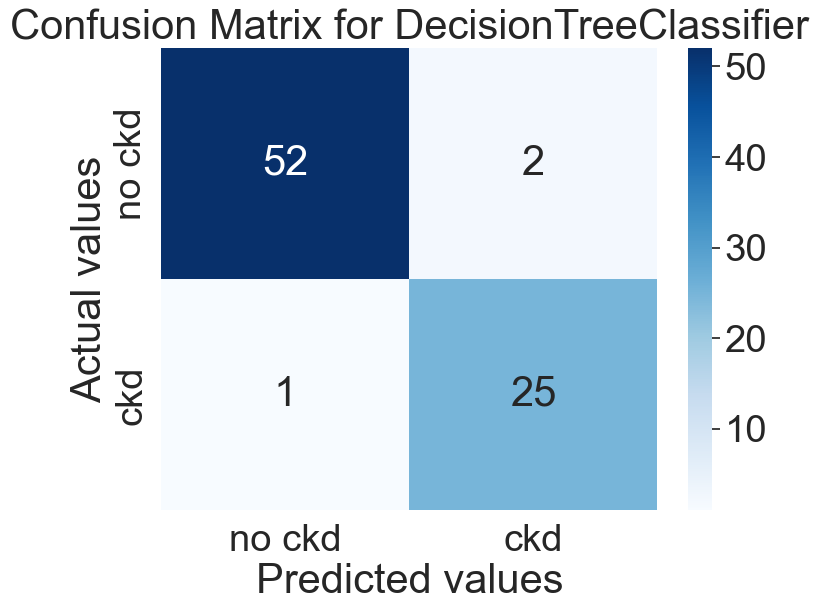

In [86]:
# Plotting confusion matrix for DecisionTreeClassifier
# Calculate predictions for Decision Tree
y_predict_dtc = dtc.predict(x_test)
cm_dtc = confusion_matrix(y_test, y_predict_dtc)
print(y_test)
print(x_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dtc, cmap='Blues', annot=True, xticklabels=['no ckd', 'ckd'], yticklabels=['no ckd', 'ckd'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix for DecisionTreeClassifier')
plt.show()

In [85]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(y_test)
print(x_test)
cm

     classification
94                0
32                0
225               0
157               0
356               1
..              ...
188               0
223               0
65                0
262               1
186               0

[80 rows x 1 columns]
     rbc  pc  bgr  bu  pe  ane  dm  cad
94     0   1   20  51   0    0   1    0
32     0   1   76  26   0    0   1    0
225    0   1  146  74   0    0   1    0
157    0   0   49  29   0    0   1    0
356    0   1   14  25   0    0   0    0
..   ...  ..  ...  ..  ..  ...  ..  ...
188    0   1    7  51   0    0   0    0
223    0   1  130  17   0    0   1    0
65     0   1   70   7   0    0   0    0
262    0   1   45   5   0    0   0    0
186    0   1   70  32   1    0   0    0

[80 rows x 8 columns]


array([[51,  3],
       [ 5, 21]])

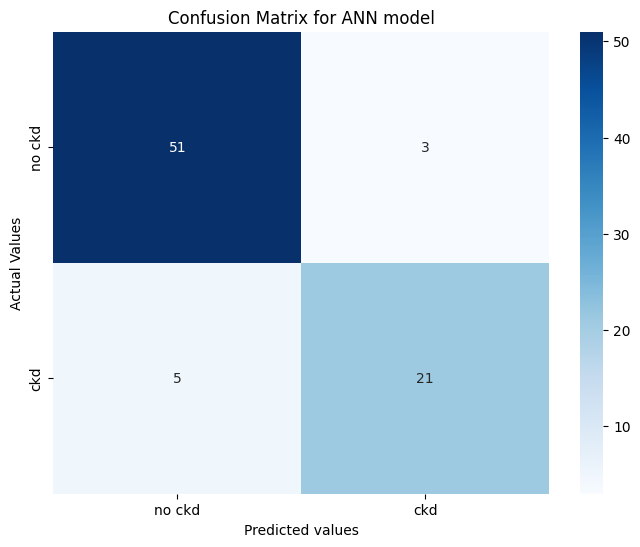

In [78]:
# Plotting confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues', annot=True, xticklabels=['no ckd', 'ckd'], yticklabels=['no ckd', 'ckd'])
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for ANN model')
plt.show()

**Evaluate the results**

In [79]:
bootstraps = []
for model in list(set(final.model.values)):
    model_df = final.loc[final.model == model]
    bootstrap = model_df.sample(n=30, replace=True)
    bootstraps.append(bootstrap)

bootstrap_df = pd.concat(bootstraps, ignore_index=True)
results_long = pd.melt(bootstrap_df,id_vars=['model'],var_name='metrics', value_name='values')
time_metrics = ['fit_time','score_time'] # fit time metrics
## PERFORMANCE METRICS
results_long_nofit = results_long.loc[~results_long['metrics'].isin(time_metrics)] # get df without fit data
results_long_nofit = results_long_nofit.sort_values(by='values')
## TIME METRICS
results_long_fit = results_long.loc[results_long['metrics'].isin(time_metrics)] # df with fit data
results_long_fit = results_long_fit.sort_values(by='values')

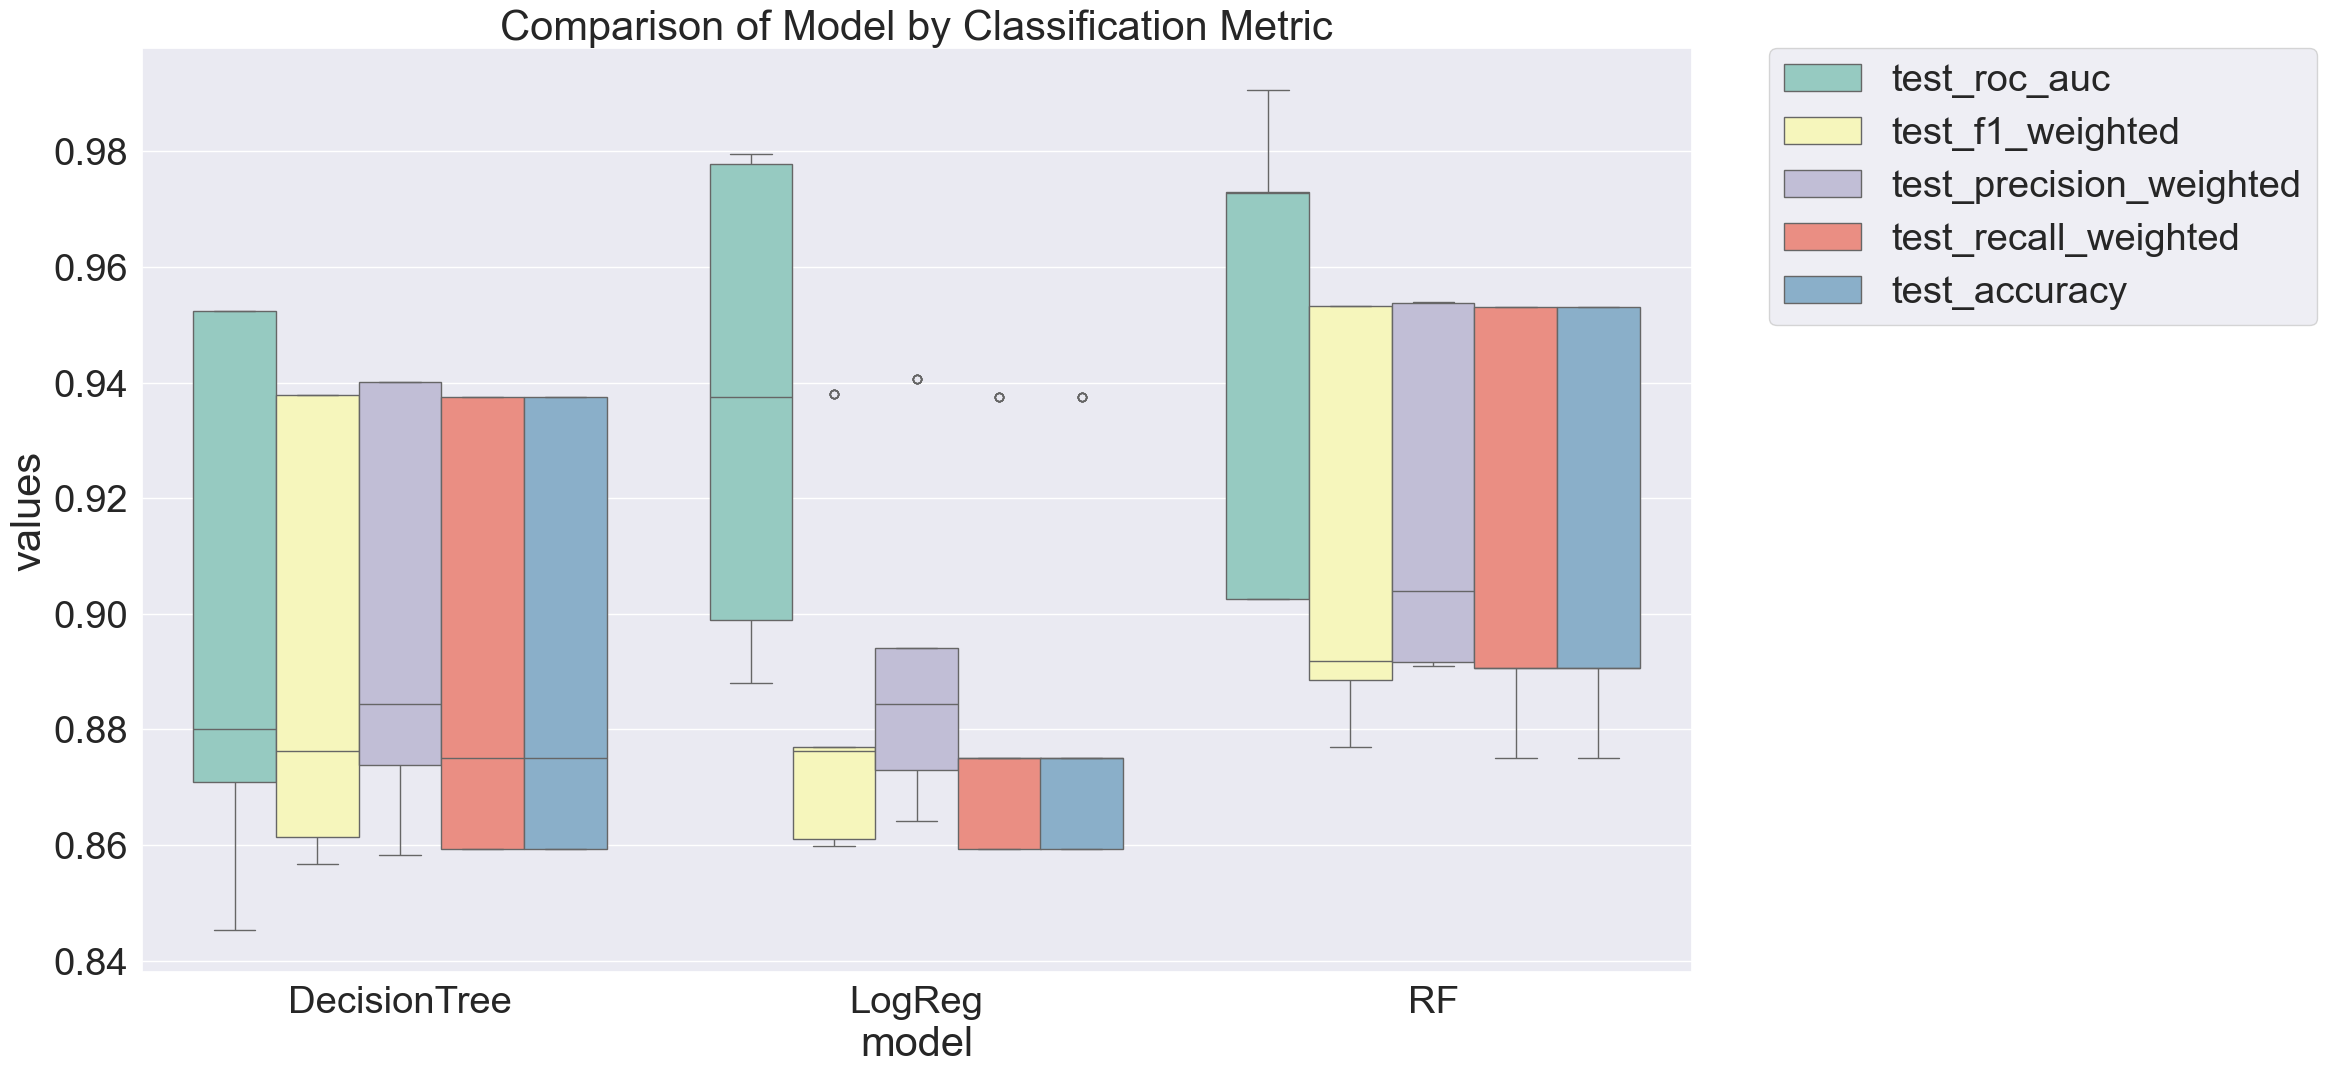

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 12))
sns.set(font_scale=2.5)
g = sns.boxplot(x="model", y="values", hue="metrics", data=results_long_nofit, palette="Set3")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Comparison of Model by Classification Metric')
plt.savefig('./benchmark_models_performance.png',dpi=300)

**Saving The Best Model**

In [84]:
import pickle
pickle.dump(lgr,open('CKD.pkl','wb'))